![image.png](attachment:8580a75f-4488-4dc5-abfa-4a2be6c3961e.png)


# Unsupervised Credit Card Fraud Detection

metadata
language

Main goal hai unusual transactions ko identify karna without depending heavily on labels during training.


## 1. Import Required Libraries

metadata
language


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_style('whitegrid')
plt.rcParams["figure.figsize"] = (12, 6)


## 2. Load the Dataset

metadata
language


In [22]:
df = pd.read_csv('creditcard.csv')
print('Rows: ' , len(df))
print('Columns: ' , df.shape[1])
df.head()


Rows:  284807
Columns:  31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Basic Data Check

metadata
language


In [23]:
print('Null values max: ' , df.isnull().sum().max())
print()
print(df['Class'].value_counts())
print()
print(df.dtypes)


Null values max:  0

Class
0    284315
1       492
Name: count, dtype: int64

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


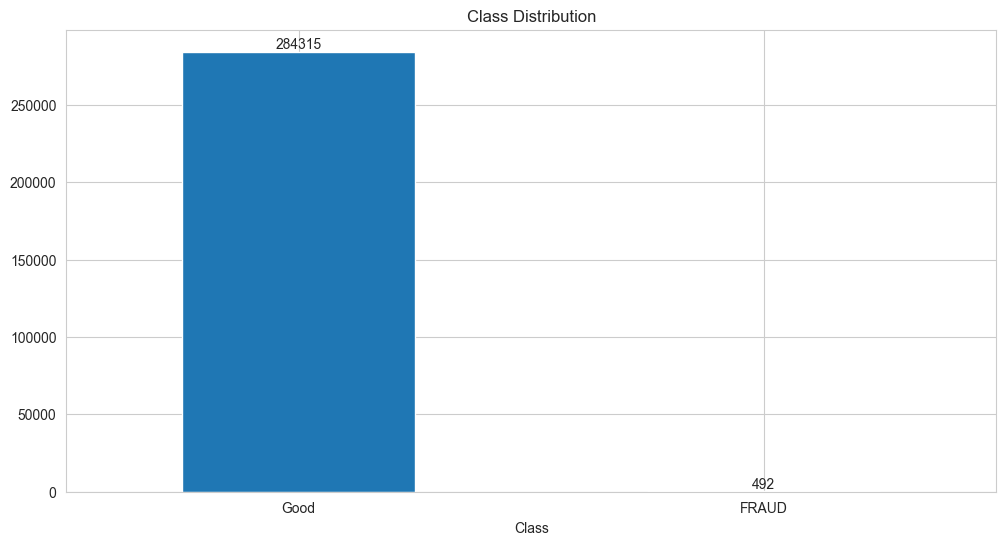

In [35]:
ax = df['Class'].value_counts().rename({0: 'Good', 1: 'FRAUD'}).plot(kind='bar', rot=0, title='Class Distribution')
ax.bar_label(ax.containers[0])
plt.show()


## 4. Preprocessing

Distance-based aur anomaly models ke liye scaling useful hoti hai. `Amount` ko robust scale karte hain aur `Time` ko standard scale karte hain.


In [36]:
data = df.copy()

amount_scaler = RobustScaler()
time_scaler = StandardScaler()

data['Amount_Scaled'] = amount_scaler.fit_transform(data[['Amount']])
data['Time_Scaled'] = time_scaler.fit_transform(data[['Time']])

data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Scaled,Time_Scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,1.783274,-1.996583
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.269825,-1.996583
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,4.983721,-1.996562
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,1.418291,-1.996562
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.670579,-1.996541


In [37]:
feature_cols = [col for col in data.columns if col.startswith('V')] + ['Amount_Scaled', 'Time_Scaled']
X = data[feature_cols]
y = data['Class']

print(X.shape)
print(y.shape)


(284807, 30)
(284807,)


## 5. Dimensionality Reduction

PCA use karke 2D me pattern dekhte hain. Ye visualization ke liye helpful hai.


In [38]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=3, max_iter=100)
kmeans_labels = kmeans.fit_predict(X)

X_np = X.values
sample_idx = np.random.choice(len(X_np), size=min(5000, len(X_np)), replace=False)
print('Silhouette Score (on 5K sample):', silhouette_score(X_np[sample_idx], kmeans_labels[sample_idx]))
print('Davies-Bouldin Score:', davies_bouldin_score(X_np, kmeans_labels))
print('Inertia:', kmeans.inertia_)


Silhouette Score (on 5K sample): 0.6342695246580657
Davies-Bouldin Score: 0.8941743431948755
Inertia: 10488198.321278367


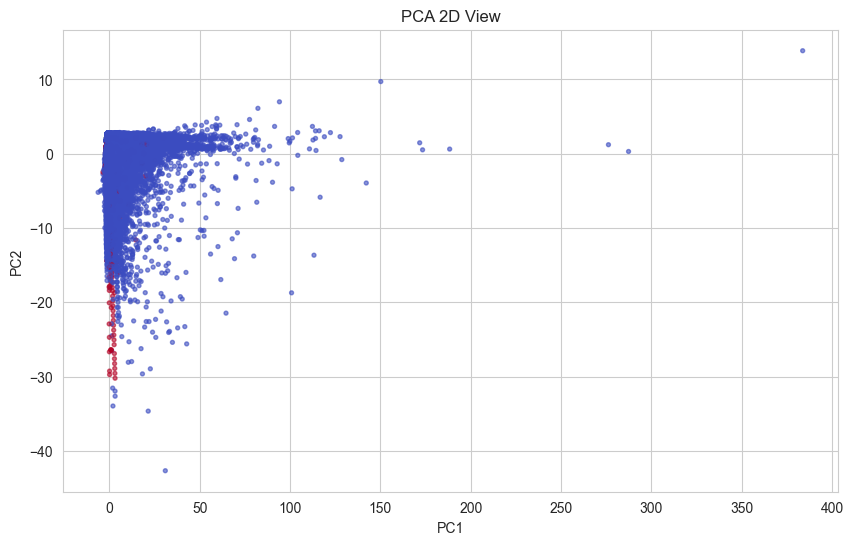

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y, cmap='coolwarm', s=8, alpha=0.6)
plt.title('PCA 2D View')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## 6. K-Means Clustering

Ab k-Means try karte hain aur see karte hain cluster quality kaisi lagti hai.


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

print('Silhouette Score:', silhouette_score(X, kmeans_labels))
print('Davies-Bouldin Score:', davies_bouldin_score(X, kmeans_labels))


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans_labels, cmap='viridis', s=8, alpha=0.6)
plt.title('K-Means Clusters on PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## 7. DBSCAN

DBSCAN me noise points anomaly-like behave kar sakte hain. Yahan direct simple tuning use karte hain.


In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X)

print('Clusters found:', len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print('Noise points:', (dbscan_labels == -1).sum())


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=dbscan_labels, cmap='tab10', s=8, alpha=0.6)
plt.title('DBSCAN on PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## 8. Isolation Forest

Ab actual anomaly detection model use karte hain. Output `-1` anomaly aur `1` normal deta hai.


In [ ]:
iso = IsolationForest(contamination=0.01, random_state=42)
iso_pred = iso.fit_predict(X)
iso_score = iso.decision_function(X)

print('Anomaly count:', (iso_pred == -1).sum())
print('Normal count:', (iso_pred == 1).sum())


## 9. Local Outlier Factor

LOF bhi outlier score deta hai. Isko compare karna useful rahega.


In [ ]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_pred = lof.fit_predict(X)
lof_score = lof.negative_outlier_factor_

print('LOF anomaly count:', (lof_pred == -1).sum())
print('LOF normal count:', (lof_pred == 1).sum())


## 10. Quick Comparison

Last me methods ka short comparison rakhte hain. Yeh notebook ko presentation-friendly banata hai.


In [ ]:
comparison = pd.DataFrame({
    'Method': ['K-Means', 'DBSCAN', 'Isolation Forest', 'LOF'],
    'Use': ['Clustering', 'Density clustering', 'Anomaly detection', 'Anomaly detection'],
    'Notes': ['Fixed clusters', 'Noise-aware', 'Fast baseline', 'Local neighborhood based']
})
comparison


## 11. Final Notes

Agar aap chaho to next version me main `XGBoost`, `Random Forest`, aur `Decision Tree` wali sections ko bhi isi style me alag-alag simple cells me convert kar dunga.


## 12. Supervised Model Comparison

Ye part optional hai, but useful hai. Yahan target `Class` ko use karke simple baseline models compare kiye gaye hain, taaki project me unsupervised ke saath supervised perspective bhi rahe.


In [16]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, f1_score, ConfusionMatrixDisplay


## 13. Train-Test Split

Yahan supervised comparison ke liye feature aur label alag karte hain.


In [17]:
Feature = df.drop(['Class'], axis=1)
Label = df['Class']

xtrain, xtest, ytrain, ytest = train_test_split(Feature, Label, test_size=0.3, random_state=42)

print('Training size:', len(ytrain))
print('Testing size:', len(ytest))
print('Fraud cases in training:', ytrain.sum())
print('Good cases in training:', len(ytrain) - ytrain.sum())
print('Fraud percentage in full data:', np.round(df['Class'].mean() * 100, 4))


Training size: 199364
Testing size: 85443
Fraud cases in training: 356
Good cases in training: 199008
Fraud percentage in full data: 0.1727


## 14. XGBoost Model

Pehla supervised baseline XGBoost hai.


F1-Score: 90.04 %
Recall: 83.09 %
Precision: 98.26 %
Test Accuracy: 99.97 %
Train Accuracy: 100.0 %


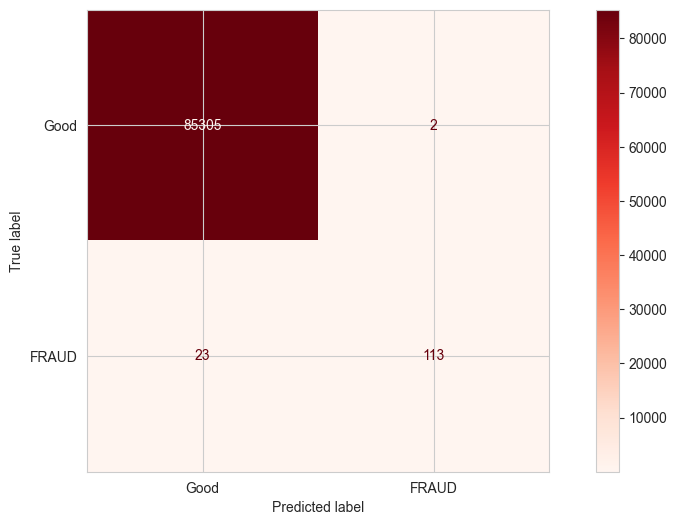

In [18]:
modelX = XGBClassifier(
    max_depth=11,
    learning_rate=0.0711,
    n_estimators=100,
    n_jobs=-1,
    random_state=42,
    eval_metric='logloss'
)

modelX.fit(xtrain, ytrain)
train_predictions = modelX.predict(xtrain)
test_predictions = modelX.predict(xtest)

train_Accuracy = accuracy_score(ytrain, train_predictions)
test_Accuracy = accuracy_score(ytest, test_predictions)
Recall = recall_score(ytest, test_predictions)
Precision = precision_score(ytest, test_predictions)
F11 = f1_score(ytest, test_predictions)
cm = confusion_matrix(ytest, test_predictions)

print('F1-Score:', round(F11 * 100, 2), '%')
print('Recall:', round(Recall * 100, 2), '%')
print('Precision:', round(Precision * 100, 2), '%')
print('Test Accuracy:', round(test_Accuracy * 100, 2), '%')
print('Train Accuracy:', round(train_Accuracy * 100, 2), '%')

ConfusionMatrixDisplay(cm, display_labels=['Good', 'FRAUD']).plot(cmap=plt.cm.Reds)
plt.show()


## 15. Random Forest Model

Random Forest ko bhi same split par compare karte hain.


F1-Score: 84.17 %
Recall: 86.03 %
Precision: 82.39 %
Test Accuracy: 99.95 %
Train Accuracy: 99.98 %


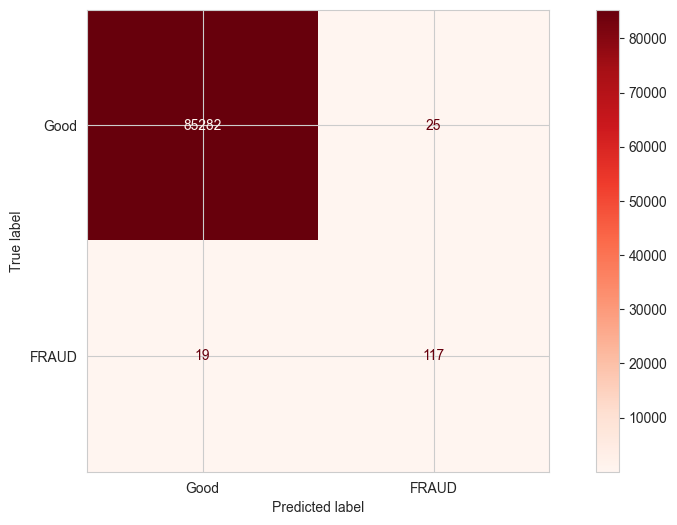

In [19]:
modelR = RandomForestClassifier(
    max_depth=10,
    n_jobs=-1,
    n_estimators=100,
    max_features='sqrt',
    random_state=42,
    min_samples_split=20,
    class_weight='balanced'
)

modelR.fit(xtrain, ytrain)
train_predictions = modelR.predict(xtrain)
test_predictions = modelR.predict(xtest)

train_Accuracy = accuracy_score(ytrain, train_predictions)
test_Accuracy = accuracy_score(ytest, test_predictions)
Recall = recall_score(ytest, test_predictions)
Precision = precision_score(ytest, test_predictions)
F11 = f1_score(ytest, test_predictions)
cm = confusion_matrix(ytest, test_predictions)

print('F1-Score:', round(F11 * 100, 2), '%')
print('Recall:', round(Recall * 100, 2), '%')
print('Precision:', round(Precision * 100, 2), '%')
print('Test Accuracy:', round(test_Accuracy * 100, 2), '%')
print('Train Accuracy:', round(train_Accuracy * 100, 2), '%')

ConfusionMatrixDisplay(cm, display_labels=['Good', 'FRAUD']).plot(cmap=plt.cm.Reds)
plt.show()


## 16. Decision Tree Model

Decision Tree ke results ko bhi alag se dekhte hain.


F1-Score: 83.15 %
Recall: 81.62 %
Precision: 84.73 %
Test Accuracy: 99.95 %
Train Accuracy: 99.94 %


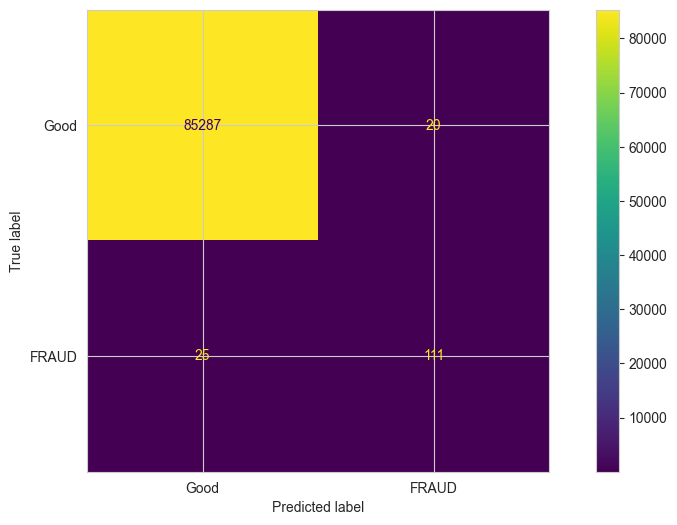

In [20]:
model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=100,
    min_samples_leaf=6,
    random_state=42,
)

model.fit(xtrain, ytrain)
train_predictions = model.predict(xtrain)
test_predictions = model.predict(xtest)

train_Accuracy = accuracy_score(ytrain, train_predictions)
test_Accuracy = accuracy_score(ytest, test_predictions)
Recall = recall_score(ytest, test_predictions)
Precision = precision_score(ytest, test_predictions)
F11 = f1_score(ytest, test_predictions)
cm = confusion_matrix(ytest, test_predictions)

print('F1-Score:', round(F11 * 100, 2), '%')
print('Recall:', round(Recall * 100, 2), '%')
print('Precision:', round(Precision * 100, 2), '%')
print('Test Accuracy:', round(test_Accuracy * 100, 2), '%')
print('Train Accuracy:', round(train_Accuracy * 100, 2), '%')

ConfusionMatrixDisplay(cm, display_labels=['Good', 'FRAUD']).plot()
plt.show()


## 17. Final Notes

Agar aap chaho to next version me feature importance aur tree plot bhi add kar sakte ho.
